In [3]:
# =========================================================
# TASK 2 - END-TO-END ML PIPELINE
# Customer Churn Prediction
# =========================================================

# =========================================================
# STEP 1 - IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Pipeline
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Export Model
import joblib

In [4]:
# =========================================================
# STEP 2 - LOAD DATASET
# =========================================================

# Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Show first rows
print(df.head())

# =========================================================
# STEP 3 - DATA EXPLORATION
# =========================================================

# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print(df.columns)

# Dataset info
print(df.info())

# Missing values
print(df.isnull().sum())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [5]:
# =========================================================
# STEP 4 - DATA CLEANING
# =========================================================

# Remove customerID column
df = df.drop("customerID", axis=1)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].mean()
)


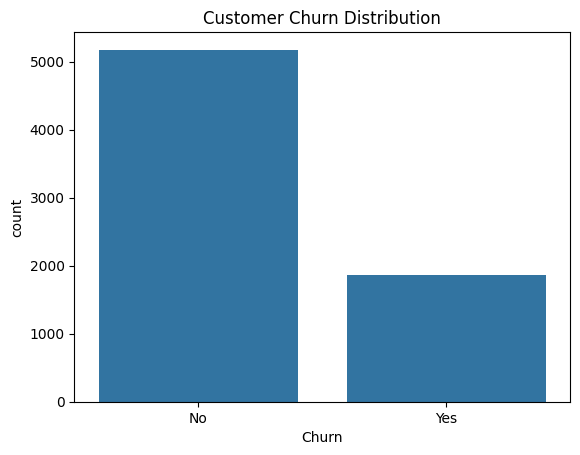

In [6]:
# =========================================================
# STEP 5 - DATA VISUALIZATION
# =========================================================

# Churn distribution
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

In [7]:
# =========================================================
# STEP 6 - CONVERT TARGET COLUMN
# =========================================================

# Yes -> 1
# No -> 0

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

# =========================================================
# STEP 7 - FEATURES AND TARGET
# =========================================================

# Input features
X = df.drop("Churn", axis=1)

# Target column
y = df["Churn"]

In [8]:
# =========================================================
# STEP 8 - IDENTIFY NUMERIC & CATEGORICAL COLUMNS
# =========================================================

# Numeric columns
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

# Categorical columns
categorical_features = X.select_dtypes(
    include=['object']
).columns

print("Numeric Columns:")
print(numeric_features)

print("Categorical Columns:")
print(categorical_features)

# =========================================================
# STEP 9 - PREPROCESSING PIPELINE
# =========================================================

# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


Numeric Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


C:\Users\Muhammad Ahsaan\AppData\Local\Temp\ipykernel_13008\1401699048.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [9]:
# =========================================================
# STEP 10 - TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================================
# STEP 11 - CREATE ML PIPELINE
# =========================================================

# Pipeline with Logistic Regression
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [10]:
# =========================================================
# STEP 12 - HYPERPARAMETER TUNING
# =========================================================

# Parameters for tuning
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['liblinear']
}

# GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy'
)

# Train model
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)


Best Parameters:
{'classifier__C': 10, 'classifier__solver': 'liblinear'}


In [11]:
# =========================================================
# STEP 13 - BEST MODEL
# =========================================================

best_model = grid_search.best_estimator_

# =========================================================
# STEP 14 - MAKE PREDICTIONS
# =========================================================

y_pred = best_model.predict(X_test)

# =========================================================
# STEP 15 - MODEL EVALUATION
# =========================================================

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

# Classification Report
print("\nClassification Report:")

print(classification_report(y_test, y_pred))


Accuracy Score: 0.8204400283889283

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



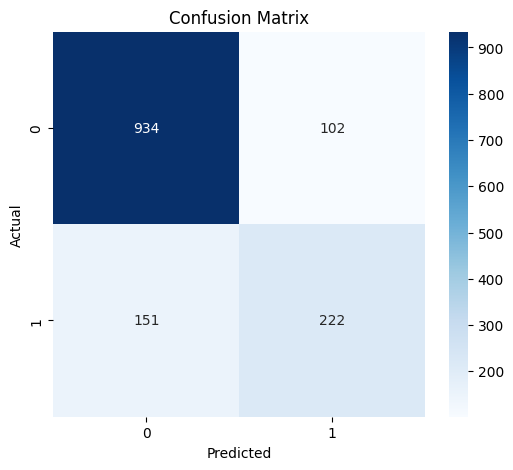

Random Forest Accuracy: 0.7913413768630234


In [12]:
# =========================================================
# STEP 16 - CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =========================================================
# STEP 17 - RANDOM FOREST MODEL
# =========================================================

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

# Train Random Forest
rf_pipeline.fit(X_train, y_train)

# Predictions
rf_pred = rf_pipeline.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

In [13]:
# =========================================================
# STEP 18 - EXPORT PIPELINE
# =========================================================

# Save model pipeline
joblib.dump(best_model, "customer_churn_pipeline.pkl")

print("Pipeline Saved Successfully!")

# =========================================================
# STEP 19 - LOAD SAVED PIPELINE
# =========================================================

# Load pipeline
loaded_pipeline = joblib.load(
    "customer_churn_pipeline.pkl"
)

print("Pipeline Loaded Successfully!")

# =========================================================
# STEP 20 - FINAL INSIGHTS
# =========================================================

print("\nFINAL INSIGHTS")

print("- ML Pipeline automated preprocessing and modeling.")
print("- Logistic Regression and Random Forest models were trained.")
print("- GridSearchCV improved model performance.")
print("- Pipeline export enables production-ready deployment.")
print("- This project demonstrates reusable ML workflow practices.")

Pipeline Saved Successfully!
Pipeline Loaded Successfully!

FINAL INSIGHTS
- ML Pipeline automated preprocessing and modeling.
- Logistic Regression and Random Forest models were trained.
- GridSearchCV improved model performance.
- Pipeline export enables production-ready deployment.
- This project demonstrates reusable ML workflow practices.
